## Titanic EDA
#### Author: Sree Karnati
#### Description: Exploratory Data Analysis on Titanic Dataset

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#Load Dataset

data = pd.read_csv(r"dataset\train.csv")

In [8]:
# Preview Dataset

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Data Cleaning

In [10]:
print("Missing values per column:\n", data.isnull().sum())

Missing values per column:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [13]:
#Fill missing Age with Median

data['Age'].fillna(data['Age'].median(), inplace=True)

C:\Users\nvina\AppData\Local\Temp\ipykernel_6404\2053789306.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)


In [14]:
#fill missing Embarked with mode

data['Embarked'].fillna(data['Embarked'].mode()[0],inplace=True)

C:\Users\nvina\AppData\Local\Temp\ipykernel_6404\1009568139.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Embarked'].fillna(data['Embarked'].mode()[0],inplace=True)


In [17]:
# Drop cabin (too many missing)

data.drop(columns=['Cabin'], inplace=True)

### Basic Statistics

In [20]:
print("Data info:\n", data.info())
print("Summary statistics:\n", data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB
Data info:
 None
Summary statistics:
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.83

### Visualizations


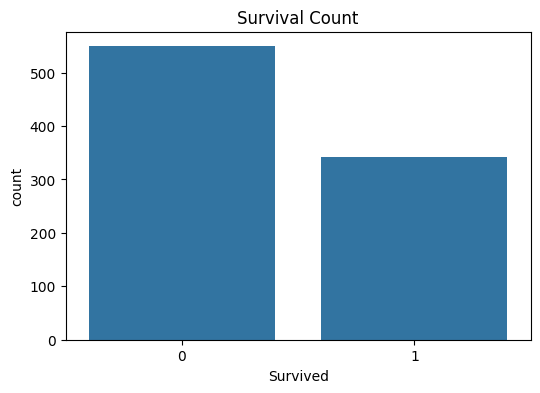

In [23]:
#Survival Count

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data= data)
plt.title('Survival Count')
plt.show()

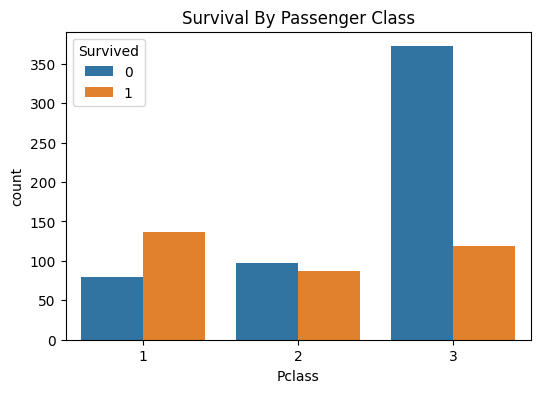

In [24]:
#Survival by passenger class

plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=data)
plt.title('Survival By Passenger Class')
plt.show()

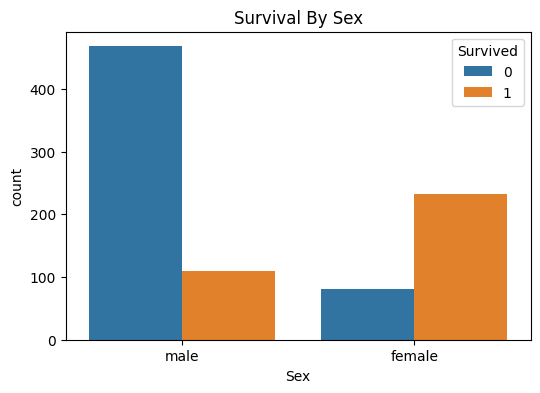

In [25]:
# Survival By Sex

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=data)
plt.title('Survival By Sex')
plt.show()


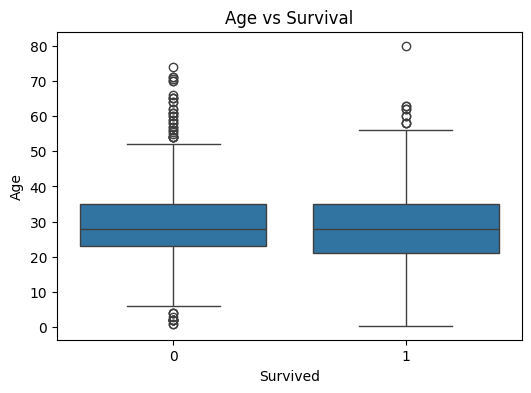

In [26]:
#Age disrtibution by survival 

plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Age', data=data)
plt.title('Age vs Survival')
plt.show()

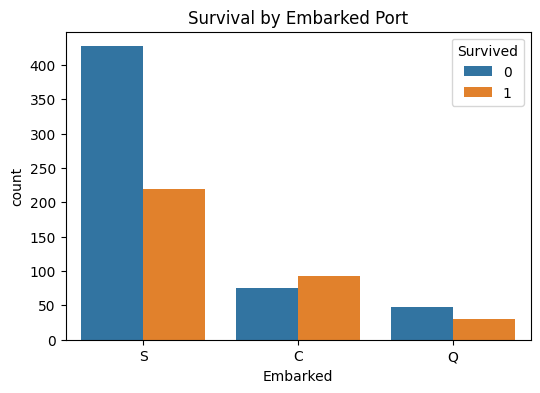

In [27]:
# Embarked vs Survival
plt.figure(figsize=(6,4))
sns.countplot(x='Embarked', hue='Survived', data=data)
plt.title('Survival by Embarked Port')
plt.show()

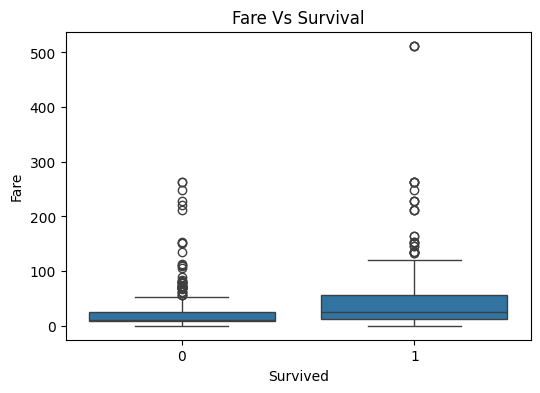

In [35]:
#Fare Distribution by Survival 

plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y= 'Fare', data=data)
plt.title("Fare Vs Survival")
plt.show()

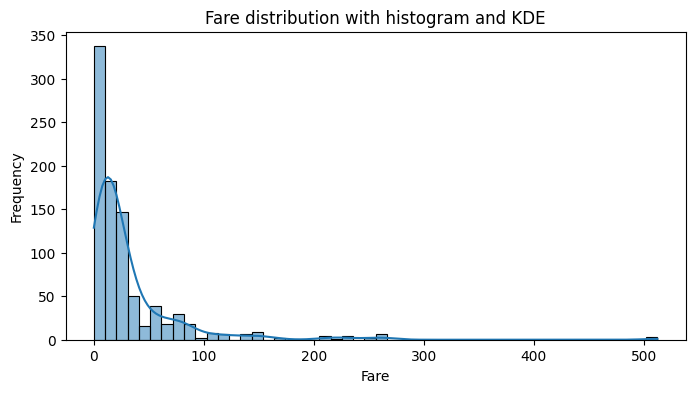

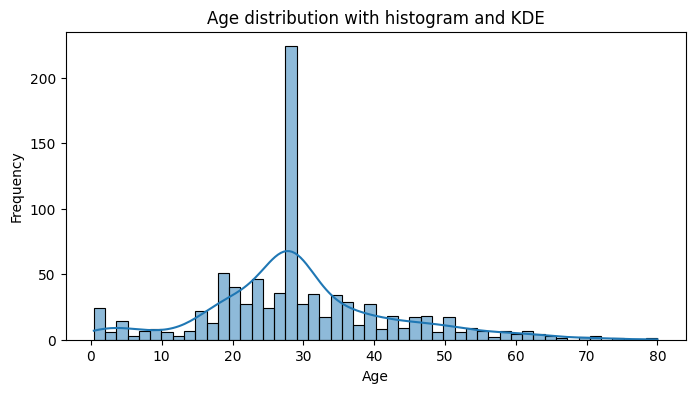

In [40]:
#Histogram

def plot_hist(variable):
    plt.figure(figsize=(8, 4))
    sns.histplot(data[variable], bins=50, kde=True)
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title(f"{variable} distribution with histogram and KDE")
    plt.show()

var = ["Fare", "Age"]
for v  in var:
    plot_hist(v)

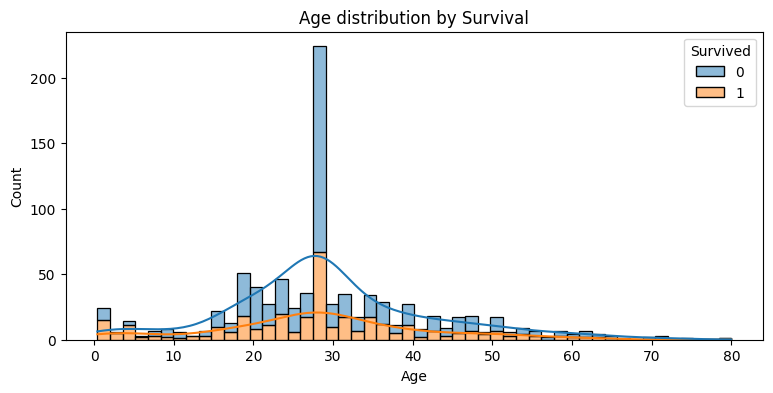

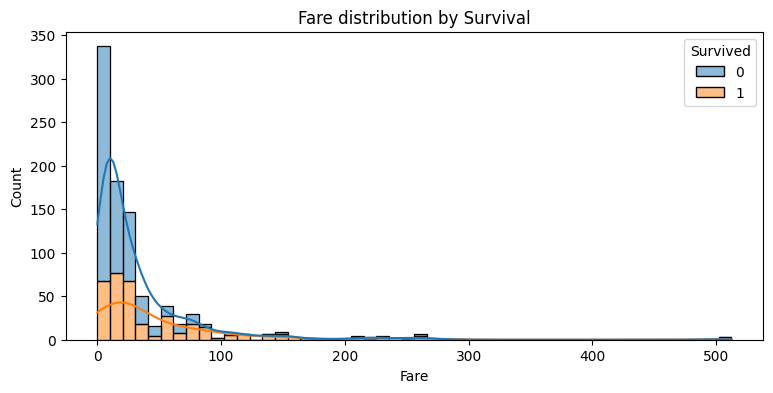

In [41]:
def plot_hist_by_survival(variable):
    plt.figure(figsize=(9,4))
    sns.histplot(data=data, x=variable, hue="Survived", bins=50, kde=True, multiple="stack")
    plt.title(f"{variable} distribution by Survival")
    plt.show()

for n in ["Age", "Fare"]:
    plot_hist_by_survival(n)

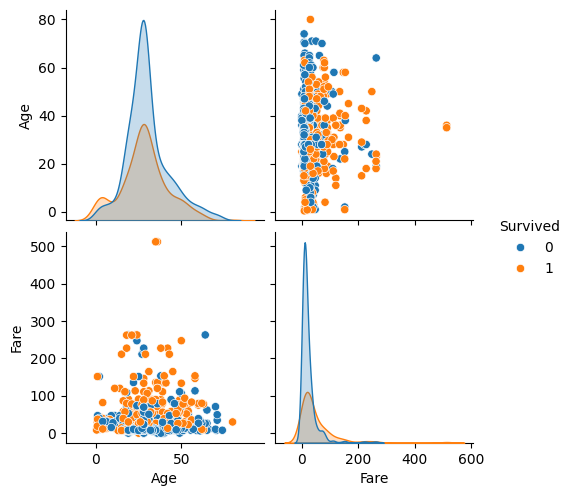

In [43]:
sns.pairplot(data, vars=['Age','Fare'], hue='Survived')
plt.show()

In [44]:
data_corr = data.copy()
data_corr['Sex'] = data_corr['Sex'].map({'male':0, 'female':1})
data_corr['Embarked'] = data_corr['Embarked'].map({'S':0, 'C':1, 'Q':2})


numeric_cols= data_corr.select_dtypes(include='number')   # Select numeric columns only

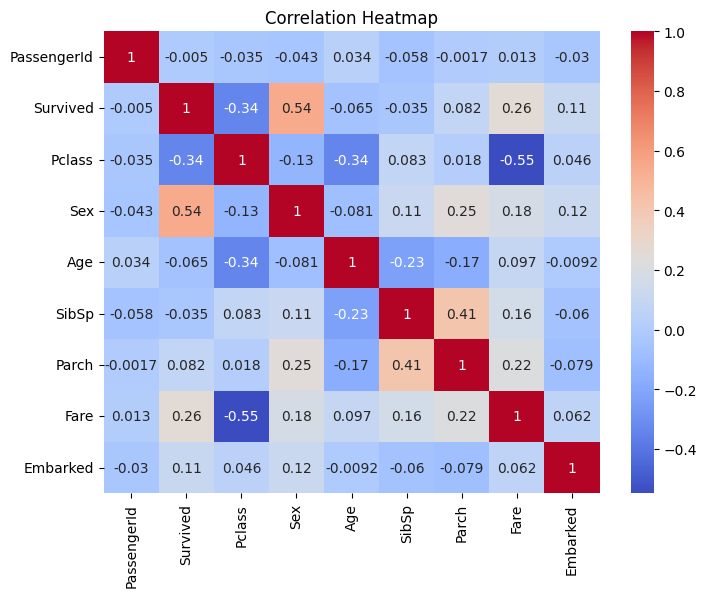

In [45]:
#Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Insights

In [46]:
print("""
Insights:
1. Passengers in 1st class had significantly higher survival rates than 3rd class.
2. Females survived much more than males, showing gender-based survival preference.
3. Passengers paying higher fares had generally higher survival, likely due to being in higher classes.
4. Age distribution shows children (around 0-12 years) had slightly higher survival rates; very old passengers had lower survival.
5. Port of Embarkation C had better survival than Q or S.
6. Correlation heatmap indicates Sex (female=1) and Fare have positive correlation with Survived.
7. Pclass shows negative correlation with Survived — lower class passengers were less likely to survive.
""")


Insights:
1. Passengers in 1st class had significantly higher survival rates than 3rd class.
2. Females survived much more than males, showing gender-based survival preference.
3. Passengers paying higher fares had generally higher survival, likely due to being in higher classes.
4. Age distribution shows children (around 0-12 years) had slightly higher survival rates; very old passengers had lower survival.
5. Port of Embarkation C had better survival than Q or S.
6. Correlation heatmap indicates Sex (female=1) and Fare have positive correlation with Survived.
7. Pclass shows negative correlation with Survived — lower class passengers were less likely to survive.

